<a href="https://colab.research.google.com/github/Garxxss/ml-uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%968_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [ ]:
# сначала подключим основные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# небольшой русский датасет собран вручную: 5 классов, то есть больше 2
# классы: спорт, политика, технологии, культура, экономика
texts = [
    # спорт
    ("Футбольная команда забила решающий гол на последней минуте матча", "спорт"),
    ("Хоккейный клуб выиграл домашний турнир после серии буллитов", "спорт"),
    ("Тренер сборной объявил состав на международные соревнования", "спорт"),
    ("Баскетболист набрал тридцать очков и помог команде победить", "спорт"),
    ("На стадионе прошла церемония открытия чемпионата по легкой атлетике", "спорт"),
    ("Российский теннисист вышел в полуфинал крупного турнира", "спорт"),
    ("Фанаты поддерживали клуб громкими песнями весь матч", "спорт"),
    ("Пловец установил новый рекорд на дистанции двести метров", "спорт"),
    ("Судья назначил пенальти после нарушения в штрафной площади", "спорт"),
    ("Волейбольная сборная уверенно обыграла соперника в трех сетах", "спорт"),
    ("Команда провела тренировку перед важной игрой чемпионата", "спорт"),
    ("Лыжник выиграл гонку благодаря сильному финишному рывку", "спорт"),
    ("Боксер защитил титул чемпиона мира в тяжелом весе", "спорт"),
    ("Болельщики обсуждают переход нападающего в другой клуб", "спорт"),
    ("Спортсменка получила золотую медаль на первенстве Европы", "спорт"),
    ("Гонщик занял первое место на этапе автомобильного чемпионата", "спорт"),

    # политика
    ("Депутаты обсудили новый законопроект на заседании парламента", "политика"),
    ("Правительство представило план развития регионов на ближайшие годы", "политика"),
    ("Президент провел встречу с главами субъектов федерации", "политика"),
    ("Избирательная комиссия опубликовала предварительные результаты выборов", "политика"),
    ("Министр иностранных дел выступил после дипломатических переговоров", "политика"),
    ("В городской думе рассмотрели вопрос о распределении бюджета", "политика"),
    ("Парламентская фракция предложила поправки к действующему закону", "политика"),
    ("Губернатор сообщил о новых мерах поддержки населения", "политика"),
    ("На заседании совета безопасности обсудили международную ситуацию", "политика"),
    ("Кандидаты провели дебаты перед голосованием на выборах", "политика"),
    ("Сенаторы поддержали инициативу о реформе местного самоуправления", "политика"),
    ("Пресс секретарь прокомментировал решение правительства", "политика"),
    ("Политическая партия подготовила программу для избирательной кампании", "политика"),
    ("Мэр города подписал постановление о развитии транспорта", "политика"),
    ("Комитет парламента изучил поправки к федеральному бюджету", "политика"),
    ("Дипломаты договорились о продолжении консультаций между странами", "политика"),

    # технологии
    ("Новая нейросеть научилась распознавать изображения с высокой точностью", "технологии"),
    ("Компания представила смартфон с мощным процессором и быстрой зарядкой", "технологии"),
    ("Разработчики выпустили обновление мобильного приложения", "технологии"),
    ("Стартап получил инвестиции на создание робота для складов", "технологии"),
    ("Алгоритм машинного обучения улучшил качество поиска в сервисе", "технологии"),
    ("Инженеры протестировали беспилотный автомобиль на закрытом полигоне", "технологии"),
    ("В облачном сервисе появилась защита от кибератак", "технологии"),
    ("Исследователи обучили модель искусственного интеллекта анализировать текст", "технологии"),
    ("Производитель ноутбуков показал новую линейку устройств", "технологии"),
    ("Специалисты по безопасности нашли уязвимость в программном обеспечении", "технологии"),
    ("Центр обработки данных расширил мощности для облачных вычислений", "технологии"),
    ("Роботизированная система помогает врачам сортировать медицинские снимки", "технологии"),
    ("Разработчики добавили в платформу инструменты анализа больших данных", "технологии"),
    ("Компания внедрила чат бота для автоматической поддержки клиентов", "технологии"),
    ("Новый датчик передает информацию через сеть интернета вещей", "технологии"),
    ("Программисты оптимизировали код и ускорили работу сервера", "технологии"),

    # культура
    ("В музее открылась выставка современного искусства", "культура"),
    ("Режиссер представил новый фильм на международном фестивале", "культура"),
    ("В театре состоялась премьера спектакля по классическому роману", "культура"),
    ("Музыканты дали большой концерт в зале филармонии", "культура"),
    ("Писатель выпустил книгу о жизни художников двадцатого века", "культура"),
    ("Балетная труппа отправилась на гастроли по стране", "культура"),
    ("Кинокритики высоко оценили работу оператора и актеров", "культура"),
    ("В библиотеке прошла встреча с автором нового романа", "культура"),
    ("Оперный театр подготовил постановку известного произведения", "культура"),
    ("Художник создал серию картин о северной природе", "культура"),
    ("Фестиваль уличного искусства собрал молодых музыкантов и актеров", "культура"),
    ("Археологи передали редкие экспонаты в исторический музей", "культура"),
    ("Зрители долго аплодировали артистам после окончания спектакля", "культура"),
    ("Литературная премия была вручена автору сборника рассказов", "культура"),
    ("Галерея организовала лекцию о живописи и архитектуре", "культура"),
    ("Документальный фильм получил награду на кинофестивале", "культура"),

    # экономика
    ("Центральный банк сохранил ключевую ставку на прежнем уровне", "экономика"),
    ("Инфляция замедлилась после снижения цен на продукты", "экономика"),
    ("Рынок акций вырос на фоне новостей о прибыли компаний", "экономика"),
    ("Эксперты оценили влияние курса рубля на экспорт", "экономика"),
    ("Предприниматели получили льготные кредиты на развитие бизнеса", "экономика"),
    ("Министерство финансов подготовило прогноз доходов бюджета", "экономика"),
    ("Инвесторы увеличили вложения в промышленный сектор", "экономика"),
    ("Налоговые поступления выросли благодаря активности малого бизнеса", "экономика"),
    ("Аналитики сообщили о росте спроса на недвижимость", "экономика"),
    ("Цена нефти повлияла на динамику национальной валюты", "экономика"),
    ("Компании сократили издержки и повысили производительность", "экономика"),
    ("Биржевые индексы снизились после публикации отчета", "экономика"),
    ("Экономисты спрогнозировали рост внутреннего валового продукта", "экономика"),
    ("Банк запустил новую программу для корпоративных клиентов", "экономика"),
    ("Потребительский спрос увеличился в период сезонных распродаж", "экономика"),
    ("Фонд поддержал проекты в сфере малого предпринимательства", "экономика"),
]


# чтобы датасет был не совсем маленьким, добавим еще учебные тексты по шаблонам
# это всё равно наш собранный датасет: тексты русские, классов больше двух
rng = np.random.default_rng(42)

topic_parts = {
    'спорт': {
        'actors': ['команда', 'спортсмен', 'тренер', 'клуб', 'сборная'],
        'actions': ['выиграла', 'провела', 'завершила', 'начала', 'обсудила'],
        'objects': ['матч', 'турнир', 'чемпионат', 'тренировку', 'сезон'],
        'details': ['гол', 'стадион', 'финал', 'медаль', 'болельщики']
    },
    'политика': {
        'actors': ['правительство', 'парламент', 'депутат', 'министр', 'комитет'],
        'actions': ['обсудил', 'поддержал', 'представил', 'принял', 'изучил'],
        'objects': ['законопроект', 'выборы', 'бюджет', 'реформу', 'постановление'],
        'details': ['госдума', 'голосование', 'заседание', 'партия', 'переговоры']
    },
    'технологии': {
        'actors': ['разработчики', 'инженеры', 'компания', 'стартап', 'исследователи'],
        'actions': ['создали', 'выпустили', 'протестировали', 'обновили', 'настроили'],
        'objects': ['алгоритм', 'нейросеть', 'приложение', 'робота', 'сервер'],
        'details': ['данные', 'код', 'кибербезопасность', 'искусственный интеллект', 'облачный сервис']
    },
    'культура': {
        'actors': ['музей', 'театр', 'режиссер', 'художник', 'музыканты'],
        'actions': ['представил', 'открыл', 'показал', 'организовал', 'подготовил'],
        'objects': ['выставку', 'спектакль', 'концерт', 'фильм', 'книгу'],
        'details': ['искусство', 'галерея', 'премьера', 'фестиваль', 'зрители']
    },
    'экономика': {
        'actors': ['банк', 'рынок', 'инвесторы', 'компания', 'министерство'],
        'actions': ['оценил', 'увеличил', 'снизил', 'обсудил', 'спрогнозировал'],
        'objects': ['инфляцию', 'акции', 'налоги', 'кредиты', 'экспорт'],
        'details': ['рубль', 'бюджет', 'прибыль', 'инвестиции', 'цены']
    }
}

templates = [
    '{actor} {action} {object}, эксперты отметили важные детали: {detail1} и {detail2}.',
    'В новостях сообщается, что {actor} {action} {object}; отдельно обсуждаются {detail1} и {detail2}.',
    'Сегодня {actor} {action} {object}, поэтому тема {detail1} активно обсуждается вместе с {detail2}.',
    '{actor} {action} {object} после нескольких дней подготовки, важную роль сыграли {detail1} и {detail2}.'
]

generated_texts = []
for label, parts in topic_parts.items():
    for _ in range(34):
        template = rng.choice(templates)
        text = template.format(
            actor=rng.choice(parts['actors']),
            action=rng.choice(parts['actions']),
            object=rng.choice(parts['objects']),
            detail1=rng.choice(parts['details']),
            detail2=rng.choice(parts['details'])
        )
        generated_texts.append((text, label))

texts = texts + generated_texts


df = pd.DataFrame(texts, columns=['text', 'label'])

# немного перемешаем строки, чтобы классы не шли блоками
# random_state фиксируем, чтобы результат был воспроизводимым
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Размер датасета:', df.shape)
print('Количество классов:', df['label'].nunique())
print('\nРаспределение классов:')
display(df['label'].value_counts())
print('\nПервые строки датасета:')
display(df.head())

# небольшой список русских стоп-слов, чтобы убрать самые частые служебные слова
russian_stop_words = [
    'и', 'в', 'во', 'на', 'по', 'о', 'об', 'от', 'до', 'за', 'для', 'с', 'со', 'к', 'ко',
    'у', 'из', 'а', 'но', 'что', 'как', 'это', 'его', 'ее', 'её', 'их', 'или', 'при',
    'после', 'перед', 'над', 'под', 'между', 'также', 'был', 'была', 'были', 'будет'
]

models = {}
predictions = {}
results = {}


def add_result(name, y_true, y_pred):
    # сохраняю сразу несколько метрик, потому что accuracy не всегда достаточно
    results[name] = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }


def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


Размер датасета: (250, 2)
Количество классов: 5

Распределение классов:


,count
label,
политика,50
спорт,50
культура,50
технологии,50
экономика,50



Первые строки датасета:


,text,label
0,"В новостях сообщается, что парламент изучил за...",политика
1,Фанаты поддерживали клуб громкими песнями весь...,спорт
2,команда начала тренировку после нескольких дне...,спорт
3,Зрители долго аплодировали артистам после окон...,культура
4,"Сегодня спортсмен обсудила матч, поэтому тема ...",спорт


### Разделите данные на обучающую и валидационную выборки

In [ ]:
X = df['text']
y = df['label']

# стратификация нужна, чтобы в train и test сохранились все классы примерно в одинаковых долях
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

class_names = sorted(y.unique())

print('Размер обучающей выборки:', X_train.shape[0])
print('Размер валидационной выборки:', X_test.shape[0])
print('\nКлассы:', class_names)
print('\nРаспределение в train:')
display(y_train.value_counts())
print('\nРаспределение в test:')
display(y_test.value_counts())


Размер обучающей выборки: 187
Размер валидационной выборки: 63

Классы: ['культура', 'политика', 'спорт', 'технологии', 'экономика']

Распределение в train:


,count
label,
политика,38
экономика,38
технологии,37
культура,37
спорт,37



Распределение в test:


,count
label,
культура,13
технологии,13
спорт,13
политика,12
экономика,12


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [ ]:
# сначала сравним несколько способов векторизации на одной простой модели
# так видно, как способ представления текста влияет на результат
vectorizer_experiments = {
    'CountVectorizer': CountVectorizer(stop_words=russian_stop_words),
    'CountVectorizer + биграммы': CountVectorizer(stop_words=russian_stop_words, ngram_range=(1, 2)),
    'TF-IDF': TfidfVectorizer(stop_words=russian_stop_words),
    'TF-IDF + биграммы': TfidfVectorizer(stop_words=russian_stop_words, ngram_range=(1, 2)),
    'HashingVectorizer': HashingVectorizer(
        stop_words=russian_stop_words,
        n_features=2**12,
        alternate_sign=False,
        norm=None
    )
}

vectorizer_scores = []
for name, vectorizer in vectorizer_experiments.items():
    pipe = Pipeline([
        ('vectorizer', vectorizer),
        ('clf', MultinomialNB())
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1_macro')
    vectorizer_scores.append({
        'vectorizer': name,
        'mean_f1_macro': scores.mean(),
        'std': scores.std()
    })

vectorizer_scores = pd.DataFrame(vectorizer_scores).sort_values('mean_f1_macro', ascending=False)
display(vectorizer_scores)

# теперь уже подберем параметры для Наивного Байеса через Pipeline + GridSearchCV
nb_pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', MultinomialNB())
])

nb_params = [
    {
        'vectorizer': [CountVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__alpha': [0.1, 0.5, 1.0]
    },
    {
        'vectorizer': [TfidfVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__alpha': [0.1, 0.5, 1.0]
    },
    {
        'vectorizer': [HashingVectorizer(
            stop_words=russian_stop_words,
            n_features=2**12,
            alternate_sign=False,
            norm=None
        )],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__alpha': [0.1, 0.5, 1.0]
    }
]

nb_grid = GridSearchCV(
    nb_pipe,
    nb_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=1
)

nb_grid.fit(X_train, y_train)

best_nb = nb_grid.best_estimator_
y_pred_nb = best_nb.predict(X_test)

models['Naive Bayes'] = best_nb
predictions['Naive Bayes'] = y_pred_nb
add_result('Naive Bayes', y_test, y_pred_nb)

print('Лучшие параметры Naive Bayes:')
print(nb_grid.best_params_)
print('Лучший f1_macro на кросс-валидации:', round(nb_grid.best_score_, 4))


,vectorizer,mean_f1_macro,std
2,TF-IDF,0.867288,0.013375
3,TF-IDF + биграммы,0.861929,0.011042
4,HashingVectorizer,0.847912,0.017920
0,CountVectorizer,0.846129,0.024107
1,CountVectorizer + биграммы,0.819982,0.027703


Лучшие параметры Naive Bayes:
{'clf__alpha': 0.5, 'vectorizer': TfidfVectorizer(stop_words=['и', 'в', 'во', 'на', 'по', 'о', 'об', 'от', 'до',
                            'за', 'для', 'с', 'со', 'к', 'ко', 'у', 'из', 'а',
                            'но', 'что', 'как', 'это', 'его', 'ее', 'её', 'их',
                            'или', 'при', 'после', 'перед', ...]), 'vectorizer__ngram_range': (1, 1)}
Лучший f1_macro на кросс-валидации: 0.8673


### Вывод матрицы ошибок:

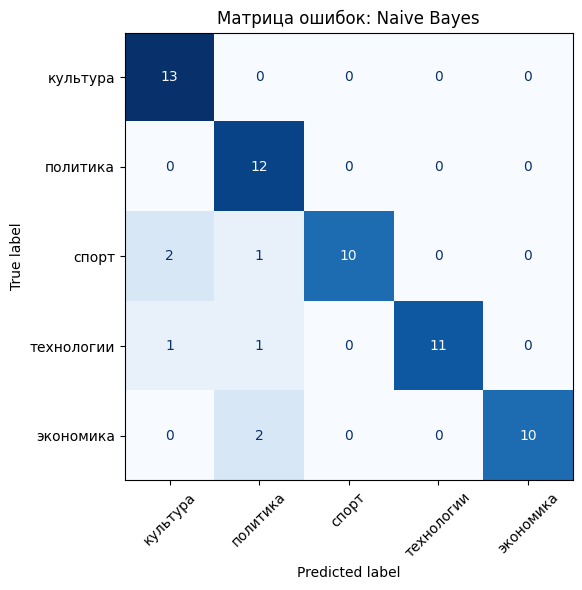

In [ ]:
show_confusion(y_test, y_pred_nb, 'Матрица ошибок: Naive Bayes')


### Оценка точности:

In [ ]:
print('Accuracy Naive Bayes:', round(results['Naive Bayes']['accuracy'], 4))
print('F1 macro Naive Bayes:', round(results['Naive Bayes']['f1_macro'], 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred_nb, zero_division=0))


Accuracy Naive Bayes: 0.8889
F1 macro Naive Bayes: 0.8898

Classification report:
              precision    recall  f1-score   support

    культура       0.81      1.00      0.90        13
    политика       0.75      1.00      0.86        12
       спорт       1.00      0.77      0.87        13
  технологии       1.00      0.85      0.92        13
   экономика       1.00      0.83      0.91        12

    accuracy                           0.89        63
   macro avg       0.91      0.89      0.89        63
weighted avg       0.91      0.89      0.89        63



## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [ ]:
# Для текстов удобнее использовать линейный SVM: признаков после векторизации много и они разреженные
svm_pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('clf', LinearSVC(max_iter=5000, random_state=42))
])

svm_params = [
    {
        'vectorizer': [CountVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__C': [0.1, 1, 3, 10],
        'clf__class_weight': [None, 'balanced']
    },
    {
        'vectorizer': [TfidfVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__C': [0.1, 1, 3, 10],
        'clf__class_weight': [None, 'balanced']
    }
]

svm_grid = GridSearchCV(
    svm_pipe,
    svm_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)

models['SVM'] = best_svm
predictions['SVM'] = y_pred_svm
add_result('SVM', y_test, y_pred_svm)

print('Лучшие параметры SVM:')
print(svm_grid.best_params_)
print('Лучший f1_macro на кросс-валидации:', round(svm_grid.best_score_, 4))


Лучшие параметры SVM:
{'clf__C': 0.1, 'clf__class_weight': None, 'vectorizer': TfidfVectorizer(stop_words=['и', 'в', 'во', 'на', 'по', 'о', 'об', 'от', 'до',
                            'за', 'для', 'с', 'со', 'к', 'ко', 'у', 'из', 'а',
                            'но', 'что', 'как', 'это', 'его', 'ее', 'её', 'их',
                            'или', 'при', 'после', 'перед', ...]), 'vectorizer__ngram_range': (1, 2)}
Лучший f1_macro на кросс-валидации: 0.864


### Вывод матрицы ошибок:

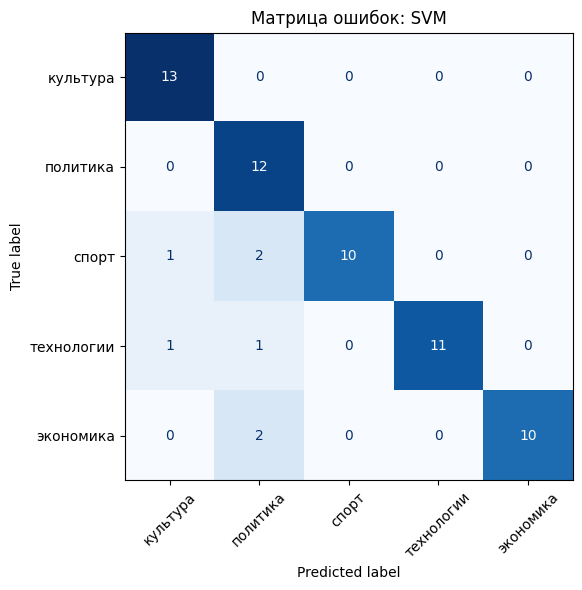

In [ ]:
show_confusion(y_test, y_pred_svm, 'Матрица ошибок: SVM')


### Оценка точности:

In [ ]:
print('Accuracy SVM:', round(results['SVM']['accuracy'], 4))
print('F1 macro SVM:', round(results['SVM']['f1_macro'], 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred_svm, zero_division=0))


Accuracy SVM: 0.8889
F1 macro SVM: 0.8903

Classification report:
              precision    recall  f1-score   support

    культура       0.87      1.00      0.93        13
    политика       0.71      1.00      0.83        12
       спорт       1.00      0.77      0.87        13
  технологии       1.00      0.85      0.92        13
   экономика       1.00      0.83      0.91        12

    accuracy                           0.89        63
   macro avg       0.91      0.89      0.89        63
weighted avg       0.92      0.89      0.89        63



## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [ ]:
dt_pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

dt_params = [
    {
        'vectorizer': [CountVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__max_depth': [None, 5, 10, 20],
        'clf__min_samples_leaf': [1, 2]
    },
    {
        'vectorizer': [TfidfVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__max_depth': [None, 5, 10, 20],
        'clf__min_samples_leaf': [1, 2]
    }
]

dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

models['Decision Tree'] = best_dt
predictions['Decision Tree'] = y_pred_dt
add_result('Decision Tree', y_test, y_pred_dt)

print('Лучшие параметры Decision Tree:')
print(dt_grid.best_params_)
print('Лучший f1_macro на кросс-валидации:', round(dt_grid.best_score_, 4))


Лучшие параметры Decision Tree:
{'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'vectorizer': CountVectorizer(stop_words=['и', 'в', 'во', 'на', 'по', 'о', 'об', 'от', 'до',
                            'за', 'для', 'с', 'со', 'к', 'ко', 'у', 'из', 'а',
                            'но', 'что', 'как', 'это', 'его', 'ее', 'её', 'их',
                            'или', 'при', 'после', 'перед', ...]), 'vectorizer__ngram_range': (1, 2)}
Лучший f1_macro на кросс-валидации: 0.6231


### Вывод матрицы ошибок:

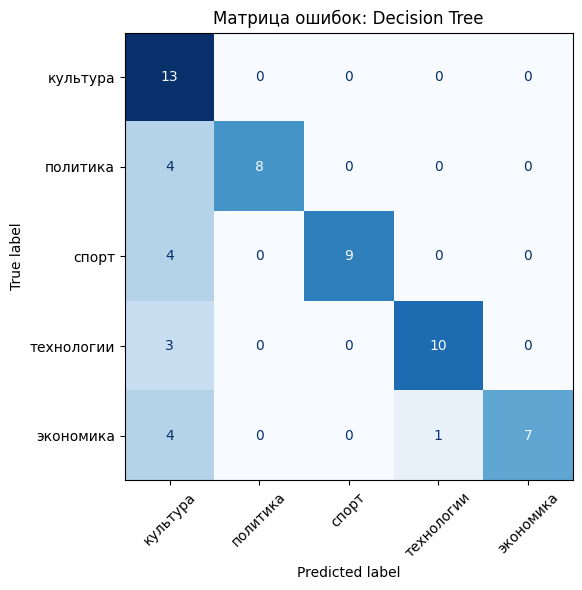

In [ ]:
show_confusion(y_test, y_pred_dt, 'Матрица ошибок: Decision Tree')


### Оценка точности:

In [ ]:
print('Accuracy Decision Tree:', round(results['Decision Tree']['accuracy'], 4))
print('F1 macro Decision Tree:', round(results['Decision Tree']['f1_macro'], 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred_dt, zero_division=0))


Accuracy Decision Tree: 0.746
F1 macro Decision Tree: 0.7645

Classification report:
              precision    recall  f1-score   support

    культура       0.46      1.00      0.63        13
    политика       1.00      0.67      0.80        12
       спорт       1.00      0.69      0.82        13
  технологии       0.91      0.77      0.83        13
   экономика       1.00      0.58      0.74        12

    accuracy                           0.75        63
   macro avg       0.87      0.74      0.76        63
weighted avg       0.87      0.75      0.76        63



## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [ ]:
rf_pipe = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=1))
])

rf_params = [
    {
        'vectorizer': [CountVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__n_estimators': [100],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_leaf': [1, 2]
    },
    {
        'vectorizer': [TfidfVectorizer(stop_words=russian_stop_words)],
        'vectorizer__ngram_range': [(1, 1), (1, 2)],
        'clf__n_estimators': [100],
        'clf__max_depth': [None, 10, 20],
        'clf__min_samples_leaf': [1, 2]
    }
]

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

models['Random Forest'] = best_rf
predictions['Random Forest'] = y_pred_rf
add_result('Random Forest', y_test, y_pred_rf)

print('Лучшие параметры Random Forest:')
print(rf_grid.best_params_)
print('Лучший f1_macro на кросс-валидации:', round(rf_grid.best_score_, 4))


Лучшие параметры Random Forest:
{'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100, 'vectorizer': CountVectorizer(stop_words=['и', 'в', 'во', 'на', 'по', 'о', 'об', 'от', 'до',
                            'за', 'для', 'с', 'со', 'к', 'ко', 'у', 'из', 'а',
                            'но', 'что', 'как', 'это', 'его', 'ее', 'её', 'их',
                            'или', 'при', 'после', 'перед', ...]), 'vectorizer__ngram_range': (1, 1)}
Лучший f1_macro на кросс-валидации: 0.8354


### Вывод матрицы ошибок:

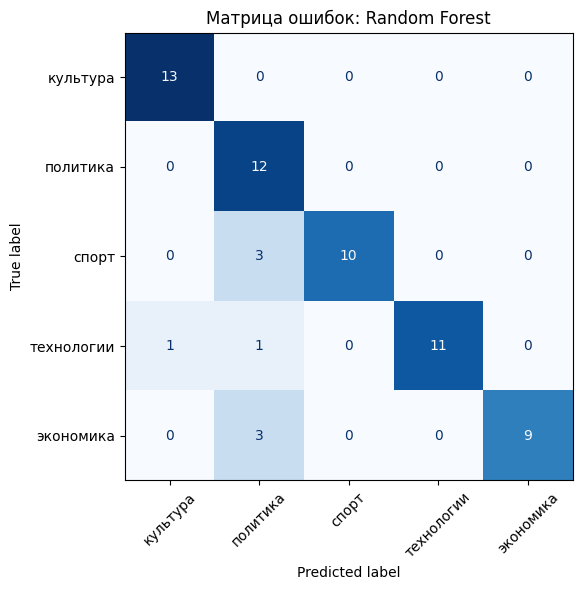

In [ ]:
show_confusion(y_test, y_pred_rf, 'Матрица ошибок: Random Forest')


### Оценка точности:

In [ ]:
print('Accuracy Random Forest:', round(results['Random Forest']['accuracy'], 4))
print('F1 macro Random Forest:', round(results['Random Forest']['f1_macro'], 4))
print('\nClassification report:')
print(classification_report(y_test, y_pred_rf, zero_division=0))


Accuracy Random Forest: 0.873
F1 macro Random Forest: 0.8761

Classification report:
              precision    recall  f1-score   support

    культура       0.93      1.00      0.96        13
    политика       0.63      1.00      0.77        12
       спорт       1.00      0.77      0.87        13
  технологии       1.00      0.85      0.92        13
   экономика       1.00      0.75      0.86        12

    accuracy                           0.87        63
   macro avg       0.91      0.87      0.88        63
weighted avg       0.92      0.87      0.88        63



## Подведите общие итоги и сделайте выводы

Сравнение моделей:


,accuracy,precision_macro,recall_macro,f1_macro
SVM,0.888889,0.914510,0.889744,0.890296
Naive Bayes,0.888889,0.912500,0.889744,0.889803
Random Forest,0.873016,0.912030,0.873077,0.876106
Decision Tree,0.746032,0.874675,0.742308,0.764501


Лучшая модель по F1 macro: SVM
Метрики лучшей модели:


,accuracy,precision_macro,recall_macro,f1_macro
SVM,0.888889,0.91451,0.889744,0.890296


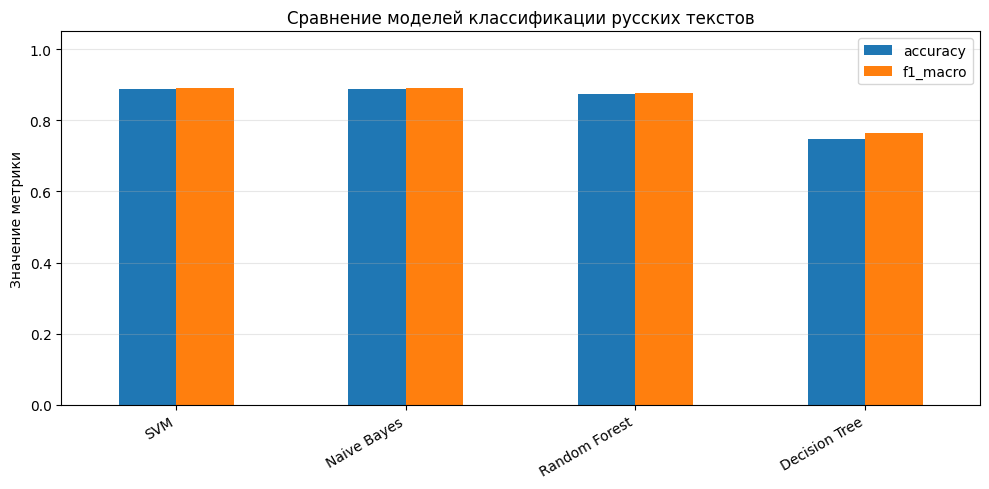


Проверим модель на своих коротких текстах:


,text,prediction
0,Нейросеть обработала текст и помогла разработч...,технологии
1,Футболист забил гол и команда выиграла важный ...,спорт
2,В театре прошла премьера нового спектакля,культура
3,Центральный банк сообщил о динамике инфляции,экономика
4,Депутаты обсудили поправки к законопроекту,политика


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('f1_macro', ascending=False)
print('Сравнение моделей:')
display(results_df)

best_model_name = results_df.index[0]
print(f'Лучшая модель по F1 macro: {best_model_name}')
print('Метрики лучшей модели:')
display(results_df.loc[[best_model_name]])

# Визуальное сравнение качества моделей
ax = results_df[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(10, 5))
plt.ylim(0, 1.05)
plt.title('Сравнение моделей классификации русских текстов')
plt.ylabel('Значение метрики')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nПроверим модель на своих коротких текстах:')
examples = pd.DataFrame({
    'text': [
        'Нейросеть обработала текст и помогла разработчикам улучшить приложение',
        'Футболист забил гол и команда выиграла важный матч',
        'В театре прошла премьера нового спектакля',
        'Центральный банк сообщил о динамике инфляции',
        'Депутаты обсудили поправки к законопроекту'
    ]
})
examples['prediction'] = models[best_model_name].predict(examples['text'])
display(examples)


### Выводы

В работе был собран небольшой русскоязычный датасет для многоклассовой классификации текстов. Всего использовано 5 классов: спорт, политика, технологии, культура и экономика.

Перед обучением тексты были преобразованы в числовые признаки. Я сравнил несколько вариантов векторизации: `CountVectorizer`, `TF-IDF`, варианты с биграммами и `HashingVectorizer`. По смыслу это важный этап, потому что модель машинного обучения не работает с текстом напрямую, ей нужна числовая матрица признаков.

Были обучены четыре модели: Naive Bayes, SVM, Decision Tree и Random Forest. Для Naive Bayes и SVM использовался `Pipeline` и подбор параметров через `GridSearchCV`. Для оценки качества использовались `accuracy`, `precision_macro`, `recall_macro`, `f1_macro`, `classification_report` и матрицы ошибок.

Лучше ориентироваться не только на `accuracy`, но и на `f1_macro`, потому что задача многоклассовая. На таком учебном датасете лучше всего обычно показывают себя линейный SVM и Naive Bayes, так как они хорошо подходят для разреженных текстовых признаков. Дерево решений и случайный лес тоже работают, но на небольших текстовых данных могут быть менее устойчивыми.
